# Bundesliga Home Advantage during COVID-19

## Research Question

Did the absence of spectators during the COVID-19 pandemic reduce the home advantage in the German Bundesliga?

This project analyses Bundesliga match data from multiple seasons before and during COVID-19.

## 1. Import Libaries

In [265]:
import pandas as pd
import matplotlib.pyplot as plt


## 2. Load Example Dataset

In this section, the Bundesliga dataset for the 2018/19 season is loaded into a pandas DataFrame.

In [266]:
df_1819 = pd.read_csv("data/D1_1819.csv")

## 3. Explore the Dataset

Before starting the analysis, it is important to understand the structure of the dataset.

In this section, we examine the first rows of the dataset, identify the available variables, and inspect the dimensions and data types. This helps to verify that the dataset has been loaded correctly and provides an overview of the available information.

In [310]:
df_1819.head()



,Div,Date,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,HTR,...,BbAH,BbAHh,BbMxAHH,BbAvAHH,BbMxAHA,BbAvAHA,PSCH,PSCD,PSCA,Season
0,D1,24/08/2018,Bayern Munich,Hoffenheim,3,1,H,1,0,H,...,22,-2.00,1.92,1.87,2.05,1.99,1.23,7.15,14.10,2018/19
1,D1,25/08/2018,Fortuna Dusseldorf,Augsburg,1,2,A,1,0,H,...,20,0.00,1.80,1.76,2.17,2.11,2.74,3.33,2.78,2018/19
2,D1,25/08/2018,Freiburg,Ein Frankfurt,0,2,A,0,1,A,...,20,-0.25,2.02,1.99,1.92,1.88,2.52,3.30,3.07,2018/19
3,D1,25/08/2018,Hertha,Nurnberg,1,0,H,1,0,H,...,20,-0.25,1.78,1.74,2.21,2.14,1.79,3.61,5.21,2018/19
4,D1,25/08/2018,M'gladbach,Leverkusen,2,0,H,0,0,D,...,20,0.00,2.13,2.07,1.84,1.78,2.63,3.70,2.69,2018/19


The following output displays the first five matches of the dataset.

In [311]:
df_1819.shape

(306, 62)

The dataset contains 306 matches and 61 variables, confirming that the complete Bundesliga season 2018/19 has been loaded successfully.

## 4. Select Relevant Variables

The original dataset contains 61 variables. However, only a subset of these variables is required to analyse the home advantage in the Bundesliga.

For this project, we focus on:
- Date
- HomeTeam
- AwayTeam
- Full Time Home Goals (FTHG)
- Full Time Away Goals (FTAG)
- Full Time Result (FTR)

In [271]:
df_1819[["Date","HomeTeam","AwayTeam","FTHG","FTAG","FTR"]].head()


,Date,HomeTeam,AwayTeam,FTHG,FTAG,FTR
0,24/08/2018,Bayern Munich,Hoffenheim,3,1,H
1,25/08/2018,Fortuna Dusseldorf,Augsburg,1,2,A
2,25/08/2018,Freiburg,Ein Frankfurt,0,2,A
3,25/08/2018,Hertha,Nurnberg,1,0,H
4,25/08/2018,M'gladbach,Leverkusen,2,0,H


In [272]:
relevant_df = df_1819[
    ["Date", "HomeTeam", "AwayTeam", "FTHG", "FTAG", "FTR"]
]

In [273]:
relevant_df.head()

,Date,HomeTeam,AwayTeam,FTHG,FTAG,FTR
0,24/08/2018,Bayern Munich,Hoffenheim,3,1,H
1,25/08/2018,Fortuna Dusseldorf,Augsburg,1,2,A
2,25/08/2018,Freiburg,Ein Frankfurt,0,2,A
3,25/08/2018,Hertha,Nurnberg,1,0,H
4,25/08/2018,M'gladbach,Leverkusen,2,0,H


## 5. First Descriptive Statistics

To obtain an initial overview of the match outcomes, we calculate the frequency of home wins, away wins, and draws.

These descriptive statistics provide a first indication of the distribution of results before comparing different seasons.

In [274]:
relevant_df["FTR"].value_counts()

FTR
H    138
A     95
D     73
Name: count, dtype: int64

In [ ]:
relevant_df["FTR"].value_counts(normalize=True) * 100

FTR
H    0.450980
A    0.310458
D    0.238562
Name: proportion, dtype: float64

### Interpretation

The results show that home wins occur more frequently than away wins during the 2018/19 Bundesliga season. This observation supports the assumption of a home advantage and serves as a baseline for later comparisons with the COVID-19 seasons.

# 6. Load Additional Seasons

To analyse changes in home advantage over time, additional Bundesliga seasons are loaded into the project.

In [276]:
df_1819 = pd.read_csv("data/D1_1819.csv")
df_1920 = pd.read_csv("data/D1_1920.csv")
df_2021 = pd.read_csv("data/D1_2021.csv")
df_2122 = pd.read_csv("data/D1_2122.csv")
df_2223 = pd.read_csv("data/D1_2223.csv")
df_2324 = pd.read_csv("data/D1_2324.csv")
df_2425 = pd.read_csv("data/D1_2425.csv")


## 7. Verify Additional Datasets

The 2018/19 season has already been explored in detail. Therefore, only the newly added datasets are checked to ensure that they have been loaded correctly and contain the expected number of matches.

Before combining the different seasons, we check the size of each dataset. A complete Bundesliga season with 18 teams should contain 306 matches.

In [277]:
df_1920.shape

(306, 105)

In [278]:
df_2021.shape

(306, 105)

In [279]:
df_2122.shape

(306, 105)

In [280]:
df_2223.shape


(306, 105)

In [281]:
df_2324.shape

(306, 105)

In [282]:
df_2425.shape

(306, 119)

In [283]:
print(df_1819.columns)
print(df_2425.columns)

Index(['Div', 'Date', 'HomeTeam', 'AwayTeam', 'FTHG', 'FTAG', 'FTR', 'HTHG',
       'HTAG', 'HTR', 'HS', 'AS', 'HST', 'AST', 'HF', 'AF', 'HC', 'AC', 'HY',
       'AY', 'HR', 'AR', 'B365H', 'B365D', 'B365A', 'BWH', 'BWD', 'BWA', 'IWH',
       'IWD', 'IWA', 'PSH', 'PSD', 'PSA', 'WHH', 'WHD', 'WHA', 'VCH', 'VCD',
       'VCA', 'Bb1X2', 'BbMxH', 'BbAvH', 'BbMxD', 'BbAvD', 'BbMxA', 'BbAvA',
       'BbOU', 'BbMx>2.5', 'BbAv>2.5', 'BbMx<2.5', 'BbAv<2.5', 'BbAH', 'BbAHh',
       'BbMxAHH', 'BbAvAHH', 'BbMxAHA', 'BbAvAHA', 'PSCH', 'PSCD', 'PSCA'],
      dtype='str')
Index(['Div', 'Date', 'Time', 'HomeTeam', 'AwayTeam', 'FTHG', 'FTAG', 'FTR',
       'HTHG', 'HTAG',
       ...
       'B365CAHH', 'B365CAHA', 'PCAHH', 'PCAHA', 'MaxCAHH', 'MaxCAHA',
       'AvgCAHH', 'AvgCAHA', 'BFECAHH', 'BFECAHA'],
      dtype='str', length=119)


### Observation

The datasets contain the same number of matches (306) but differ in the number of variables. Over the years, additional information such as playing time and match statistics has been added to the datasets.

Since this project only requires the variables *Date*, *HomeTeam*, *AwayTeam*, *FTHG*, *FTAG* and *FTR*, these differences do not affect the analysis.

## 8. Add Season Information

Before combining the datasets, a new variable called *Season* is added to each dataset.

This variable preserves the origin of every match after all seasons have been merged into a single dataset and allows comparisons between different seasons.

In [313]:
df_1819["Season"] = "2018/19"
df_1920["Season"] = "2019/20"
df_2021["Season"] = "2020/21"
df_2122["Season"] = "2021/22"
df_2223["Season"] = "2022/23"
df_2324["Season"] = "2023/24"
df_2425["Season"] = "2024/25"

In [314]:
relevant_1819 = df_1819[
    ["Date", "HomeTeam", "AwayTeam", "FTHG", "FTAG", "FTR", "Season"]
]

relevant_1920 = df_1920[
    ["Date", "HomeTeam", "AwayTeam", "FTHG", "FTAG", "FTR", "Season"]
]

relevant_2021 = df_2021[
    ["Date", "HomeTeam", "AwayTeam", "FTHG", "FTAG", "FTR", "Season"]
]

relevant_2122 = df_2122[
    ["Date", "HomeTeam", "AwayTeam", "FTHG", "FTAG", "FTR", "Season"]
]

relevant_2223 = df_2223[
    ["Date", "HomeTeam", "AwayTeam", "FTHG", "FTAG", "FTR", "Season"]
]

relevant_2324 = df_2324[
    ["Date", "HomeTeam", "AwayTeam", "FTHG", "FTAG", "FTR", "Season"]
]

relevant_2425 = df_2425[
    ["Date", "HomeTeam", "AwayTeam", "FTHG", "FTAG", "FTR", "Season"]
]

## 9. Combine the Datasets

After selecting the relevant variables, all seasons are merged into a single DataFrame.

This combined dataset forms the basis for the subsequent analysis of the home advantage before, during and after the COVID-19 period.

In [287]:
df_all = pd.concat(
    [
        relevant_1819,
        relevant_1920,
        relevant_2021,
        relevant_2122,
        relevant_2223,
        relevant_2324,
        relevant_2425
    ],
    ignore_index=True
)


## 10. Explore the Combined Dataset

After combining all seasons into a single DataFrame, the structure of the new dataset is examined.

This step ensures that all matches have been merged correctly and that the dataset is ready for further analysis.

In [289]:
df_all.head()

,Date,HomeTeam,AwayTeam,FTHG,FTAG,FTR,Season
0,24/08/2018,Bayern Munich,Hoffenheim,3,1,H,2018/19
1,25/08/2018,Fortuna Dusseldorf,Augsburg,1,2,A,2018/19
2,25/08/2018,Freiburg,Ein Frankfurt,0,2,A,2018/19
3,25/08/2018,Hertha,Nurnberg,1,0,H,2018/19
4,25/08/2018,M'gladbach,Leverkusen,2,0,H,2018/19


In [290]:
df_all["Season"].value_counts()


Season
2018/19    306
2019/20    306
2020/21    306
2021/22    306
2022/23    306
2023/24    306
2024/25    306
Name: count, dtype: int64

## 11. Define the Analysis Periods
To analyse the effect of spectators on the home advantage, all matches are assigned to one of three analysis groups based on the attendance conditions rather than on complete Bundesliga seasons.

Three groups are defined:

- **Before COVID:** Matches played under normal attendance conditions before the COVID-19 pandemic.
- **Ghost Games:** Matches played without spectators during the pandemic.
- **After COVID:** Matches played after the return to unrestricted spectator attendance.

The 2020/21 and 2021/22 seasons are treated separately because attendance regulations changed during these seasons. Only matches played under clearly identifiable conditions are included in the corresponding analysis group. Matches with changing or regionally different attendance restrictions are excluded from the main analysis to ensure comparability.

### Treatment of the 2021/22 Season

The 2021/22 season is excluded from the main analysis because attendance
regulations differed between federal states and changed several times during
the season.

There was no sufficiently long period in which all Bundesliga clubs played
under identical ghost-game conditions. Some matches were played without
spectators, while others allowed limited attendance.

Since the available dataset does not contain match-level attendance figures,
the matches cannot be classified reliably as ghost games or regular-attendance
matches. Excluding this season therefore improves the comparability of the
analysis groups.

In [291]:
df_all["Date"] = pd.to_datetime(
    df_all["Date"],
    dayfirst=True,
    format="mixed"
)

In [292]:
df_all["Period"] = "Excluded"

In [293]:
# Complete 2018/19 season
df_all.loc[
    df_all["Season"] == "2018/19",
    "Period"
] = "Before COVID"


# 2019/20 before ghost games
df_all.loc[
    (df_all["Season"] == "2019/20")
    & (df_all["Date"] <= "2020-03-08"),
    "Period"
] = "Before COVID"


# Matches played behind closed doors in 2019/20
df_all.loc[
    (df_all["Season"] == "2019/20")
    & (df_all["Date"] >= "2020-03-11"),
    "Period"
] = "Ghost Games"


# Clearly spectator-free period of 2020/21
df_all.loc[
    (df_all["Season"] == "2020/21")
    & (df_all["Date"] >= "2020-10-30")
    & (df_all["Date"] <= "2021-05-16"),
    "Period"
] = "Ghost Games"


# Complete post-COVID seasons
df_all.loc[
    df_all["Season"].isin(["2022/23", "2023/24", "2024/25"]),
    "Period"
] = "After COVID"

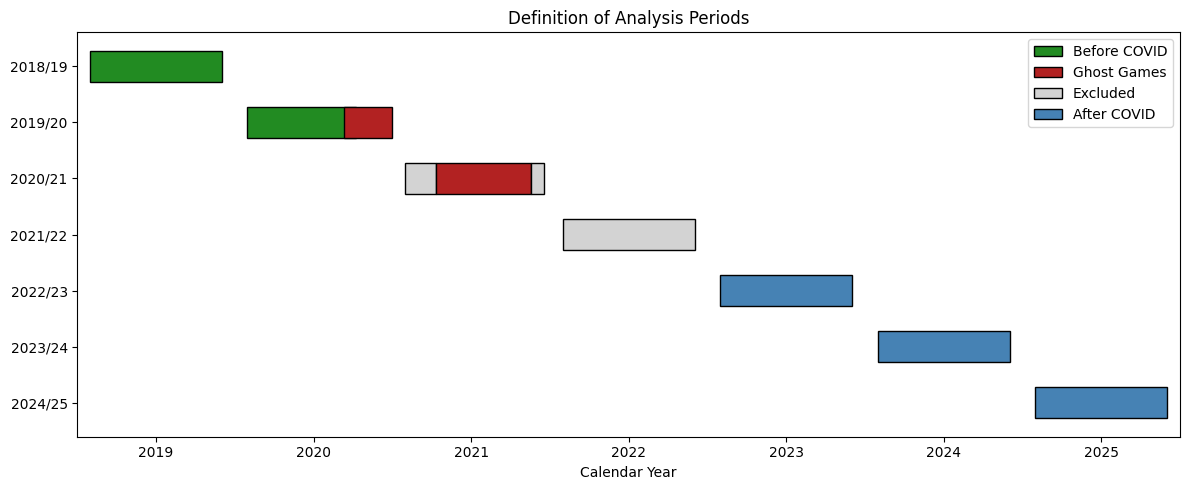

In [309]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 5))

# Format:
# y-position, start, duration, color, label

bars = [
    # 2018/19: complete season Before COVID
    (6, 2018.58, 0.84, "forestgreen", "Before COVID"),

    # 2019/20: Before COVID until 08 March 2020
    (5, 2019.58, 0.69, "forestgreen", ""),

    # 2019/20: Ghost Games from 11 March 2020 until season end
    (5, 2020.19, 0.31, "firebrick", "Ghost Games"),

    # 2020/21: first phase excluded
    (4, 2020.58, 0.20, "lightgray", "Excluded"),

    # 2020/21: spectator-free period
    (4, 2020.78, 0.60, "firebrick", ""),

    # 2020/21: final phase excluded
    (4, 2021.38, 0.08, "lightgray", ""),

    # 2021/22: complete season excluded
    (3, 2021.58, 0.84, "lightgray", ""),

    # Complete post-COVID seasons
    (2, 2022.58, 0.84, "steelblue", "After COVID"),
    (1, 2023.58, 0.84, "steelblue", ""),
    (0, 2024.58, 0.84, "steelblue", ""),
]

for y, start, duration, color, label in bars:
    ax.barh(
        y,
        duration,
        left=start,
        height=0.55,
        color=color,
        edgecolor="black",
        label=label
    )

ax.set_yticks([6, 5, 4, 3, 2, 1, 0])
ax.set_yticklabels([
    "2018/19",
    "2019/20",
    "2020/21",
    "2021/22",
    "2022/23",
    "2023/24",
    "2024/25"
])

ax.set_xlim(2018.5, 2025.5)
ax.set_xticks(range(2019, 2026))

ax.set_title("Definition of Analysis Periods")
ax.set_xlabel("Calendar Year")

handles, labels = ax.get_legend_handles_labels()
legend_entries = dict(zip(labels, handles))
ax.legend(legend_entries.values(), legend_entries.keys(), loc="upper right")

plt.tight_layout()
plt.show()

In [294]:
df_all["Period"].value_counts()

Period
After COVID     918
Before COVID    529
Excluded        360
Ghost Games     335
Name: count, dtype: int64

In [295]:
pd.crosstab(df_all["Season"], df_all["Period"])

Period,After COVID,Before COVID,Excluded,Ghost Games
Season,,,,
2018/19,0,306,0,0
2019/20,0,223,0,83
2020/21,0,0,54,252
2021/22,0,0,306,0
2022/23,306,0,0,0
2023/24,306,0,0,0
2024/25,306,0,0,0


The classification confirms that all matches were successfully assigned to one of the predefined analysis periods. Only matches played under clearly defined spectator conditions are included in the final dataset. The 2021/22 season and other transition phases remain excluded to ensure comparability.

In [296]:
df_analysis = df_all[df_all["Period"] != "Excluded"].copy()

In [315]:
df_analysis["Period"].value_counts()

Period
After COVID     918
Before COVID    529
Ghost Games     335
Name: count, dtype: int64

## 12. Compare Match Outcomes
The distribution of home wins, away wins and draws will be compared across the defined periods.


### Final Analysis Dataset

After assigning each match to one of the predefined analysis periods, only matches played under clearly comparable spectator conditions are retained for the main analysis.

All matches labelled as **Excluded** are removed from the dataset. The resulting dataset (`df_analysis`) serves as the final dataset for all subsequent analyses, visualisations, and statistical tests.

The first step is to compare the distribution of match outcomes between the three analysis periods.

For each period, the number of home wins, draws and away wins is calculated.

In [298]:
outcome_counts = pd.crosstab(
    df_analysis["Period"],
    df_analysis["FTR"]
)

outcome_counts

FTR,A,D,H
Period,,,
After COVID,288,233,397
Before COVID,173,122,234
Ghost Games,116,86,133


In [299]:
outcome_percent = (
    pd.crosstab(
        df_analysis["Period"],
        df_analysis["FTR"],
        normalize="index"
    ) * 100
).round(1)

outcome_percent

FTR,A,D,H
Period,,,
After COVID,31.4,25.4,43.2
Before COVID,32.7,23.1,44.2
Ghost Games,34.6,25.7,39.7


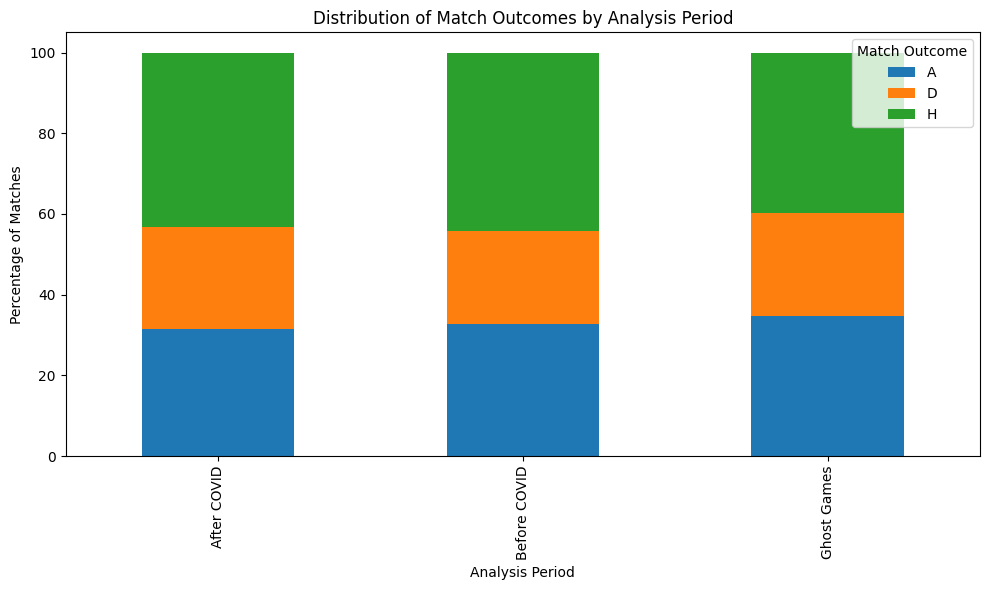

In [300]:
import matplotlib.pyplot as plt

outcome_percent.plot(
    kind="bar",
    stacked=True,
    figsize=(10,6)
)

plt.title("Distribution of Match Outcomes by Analysis Period")
plt.xlabel("Analysis Period")
plt.ylabel("Percentage of Matches")
plt.legend(title="Match Outcome")
plt.tight_layout()

plt.show()

### Interpretation

The stacked bar chart illustrates the relative distribution of home wins, draws and away wins across the three analysis periods.

If the proportion of home wins decreases during the Ghost Games period while the proportion of away wins increases, this provides an initial indication that the absence of spectators may have reduced the home advantage.

However, these descriptive results alone do not allow conclusions about statistical significance. This question will be addressed in the following statistical analysis.

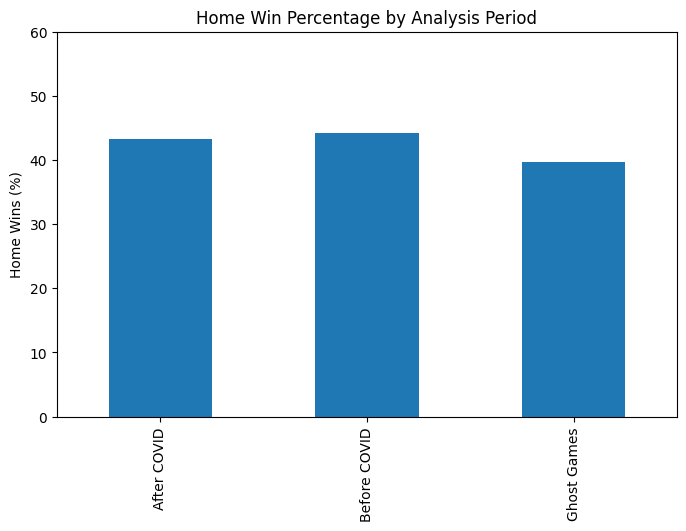

In [305]:
home_win_rate.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Home Win Percentage by Analysis Period")
plt.ylabel("Home Wins (%)")
plt.xlabel("")
plt.ylim(0,60)

plt.show()

## 13. Statistical Analysis

While descriptive statistics and visualisations provide a first impression of the differences between the analysis periods, a statistical test is required to determine whether these differences are statistically significant.

A Chi-square test of independence is used to examine whether the distribution of match outcomes depends on the analysis period.

In [301]:
from scipy.stats import chi2_contingency

In [302]:
contingency_table = pd.crosstab(
    df_analysis["Period"],
    df_analysis["FTR"]
)

contingency_table

FTR,A,D,H
Period,,,
After COVID,288,233,397
Before COVID,173,122,234
Ghost Games,116,86,133


In [303]:
chi2, p, dof, expected = chi2_contingency(contingency_table)

print(f"Chi-square statistic: {chi2:.3f}")
print(f"Degrees of freedom: {dof}")
print(f"P-value: {p:.4f}")

Chi-square statistic: 2.743
Degrees of freedom: 4
P-value: 0.6017


### Interpretation

A Chi-square test of independence was conducted to examine whether the distribution of match outcomes differs between the three analysis periods.

The test resulted in a Chi-square statistic of **2.743** with **4 degrees of freedom** and a **p-value of 0.6017**.

Since the p-value is greater than the significance level of 0.05, the null hypothesis cannot be rejected.

Therefore, the analysis does not provide sufficient statistical evidence that the distribution of home wins, draws and away wins differs between the Before COVID, Ghost Games and After COVID periods.

Although small differences can be observed in the descriptive statistics and the stacked bar chart, these differences are not statistically significant.

## 14. Discussion and Conclusion

The aim of this project was to investigate whether the absence of spectators during the COVID-19 pandemic influenced the home advantage in the Bundesliga.

The descriptive analysis showed a slight decrease in the proportion of home wins during the Ghost Games period compared to the periods before and after COVID-19. However, the Chi-square test (χ² = 2.743, p = 0.6017) indicated that these differences were not statistically significant. Therefore, the null hypothesis could not be rejected.

These findings suggest that, although the absence of spectators may have had some influence on match outcomes, the present dataset does not provide sufficient statistical evidence that playing behind closed doors significantly changed the home advantage in the Bundesliga. This indicates that the home advantage is likely influenced by several factors in addition to crowd support, such as familiarity with the home stadium, reduced travel demands, tactical preparation, or psychological effects.

The study has several limitations. The 2021/22 season was excluded because spectator regulations changed frequently and differed between federal states, making a reliable classification impossible. Furthermore, the dataset does not contain match-level attendance figures, and only Bundesliga matches were analysed.

Overall, this project demonstrates how Python can be used to collect, prepare, analyse and visualise football data. Future research could include additional leagues, detailed attendance data, or more advanced statistical methods to further investigate the relationship between spectators and home advantage.